# Model training and evaluation

In [1]:
import sys
sys.path.append("..")
import pandas as pd
from IPython.display import Image, display
from src.utils import RAW_DATA_PATH,FIGURES_DIR,set_seed
from src.train import main as run_training 

# Run the full pipeline

In [2]:
from src.utils import TARGET_COLUMN
print(TARGET_COLUMN)

target


In [3]:
set_seed()
results, best_model_name = run_training(data_path=RAW_DATA_PATH, cv_folds=5,positive_label='good')
print('Best model:', best_model_name)

2026-07-09 15:36:44 | INFO     | src.preprocessing | Loading raw data from C:\Users\mohit\Credit-scoring-model\data\raw\credit_data.csv
2026-07-09 15:36:44 | INFO     | src.preprocessing | Loaded 1000 rows, 21 columns
2026-07-09 15:36:44 | INFO     | src.preprocessing | Dropped 0 duplicate rows
2026-07-09 15:36:44 | INFO     | src.preprocessing | Encoding target 'target' -> {'good': 1, 'bad': 0}
2026-07-09 15:36:44 | INFO     | src.features | Feature engineering complete -> 24 columns
2026-07-09 15:36:44 | INFO     | src.train | Processed dataset saved to C:\Users\mohit\Credit-scoring-model\data\processed\processed_credit_data.csv
2026-07-09 15:36:44 | INFO     | src.preprocessing | Split data -> train: 800 rows, test: 200 rows (train default rate=70.00%, test default rate=70.00%)
2026-07-09 15:36:44 | INFO     | src.train | Numeric features (9): ['month_duration', 'credit_amount', 'payment_to_income_ratio', 'residence_since', 'age', 'n_credits', 'n_guarantors', 'credit_mix_score', 'in

Best model: random_forest


# Metrics comparison table


In [4]:
rows=[]
for name, m in results.items():
    rows.append({k:v for k,v in m.items() if k in ['model','accuracy','precision','recall','f1_score','roc_auc']})
comparison_df=pd.DataFrame(rows).sort_values('roc_auc',ascending=False).reset_index(drop=True)
comparison_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,random_forest,0.770,0.835714,0.835714,0.835714,0.821190
1,logistic_regression,0.730,0.762195,0.892857,0.822368,0.790238
2,decision_tree,0.755,0.786164,0.892857,0.836120,0.735476


# Visual Diagnostics

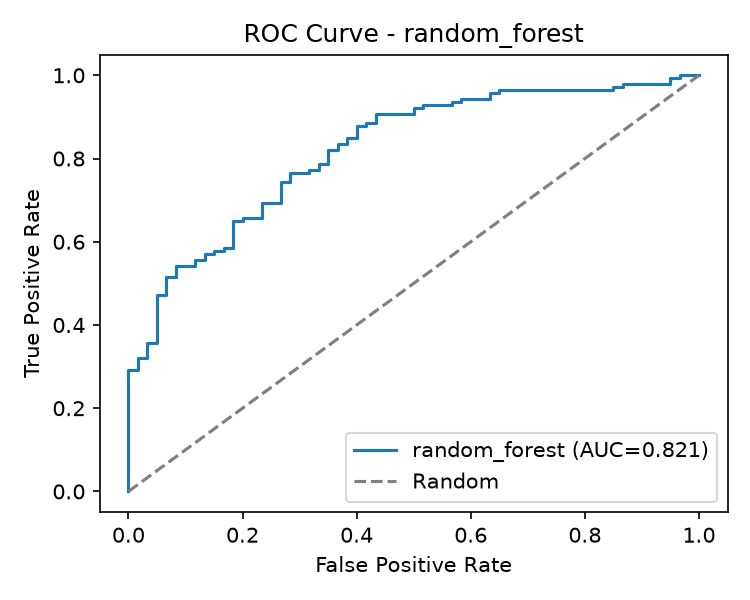

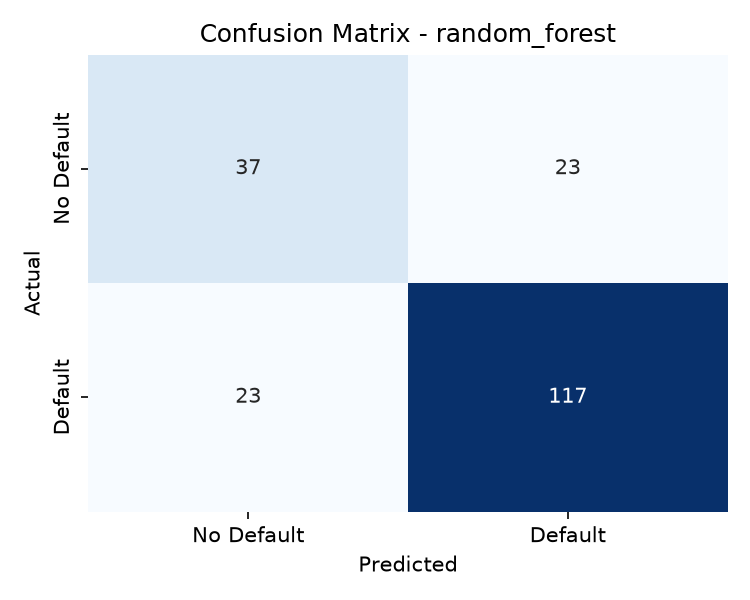

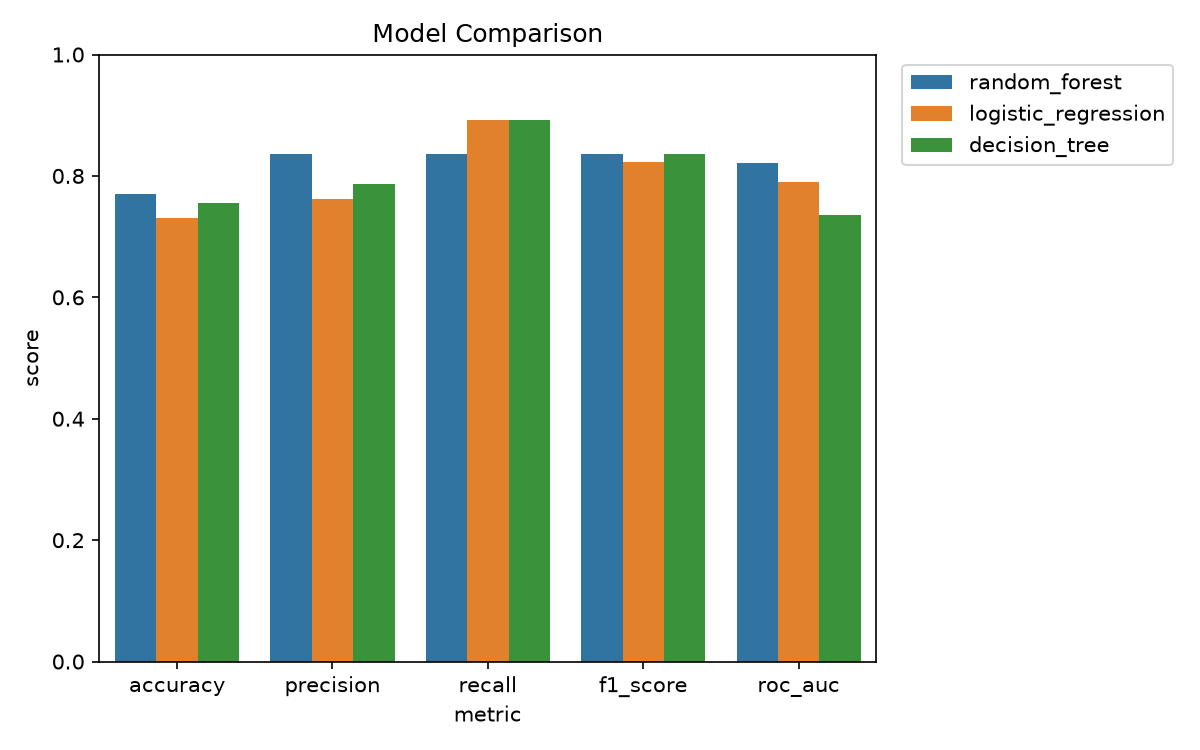

In [5]:
display(Image(filename=str(FIGURES_DIR / f'roc_curve_{best_model_name}.png')))
display(Image(filename=str(FIGURES_DIR / f'confusion_matrix_{best_model_name}.png')))
display(Image(filename=str(FIGURES_DIR / 'model_comparison.png')))

2026-07-09 15:48:34 | INFO     | src.evaluate | Saved feature importance plot -> C:\Users\mohit\Credit-scoring-model\outputs\figures\feature_importance_random_forest.png


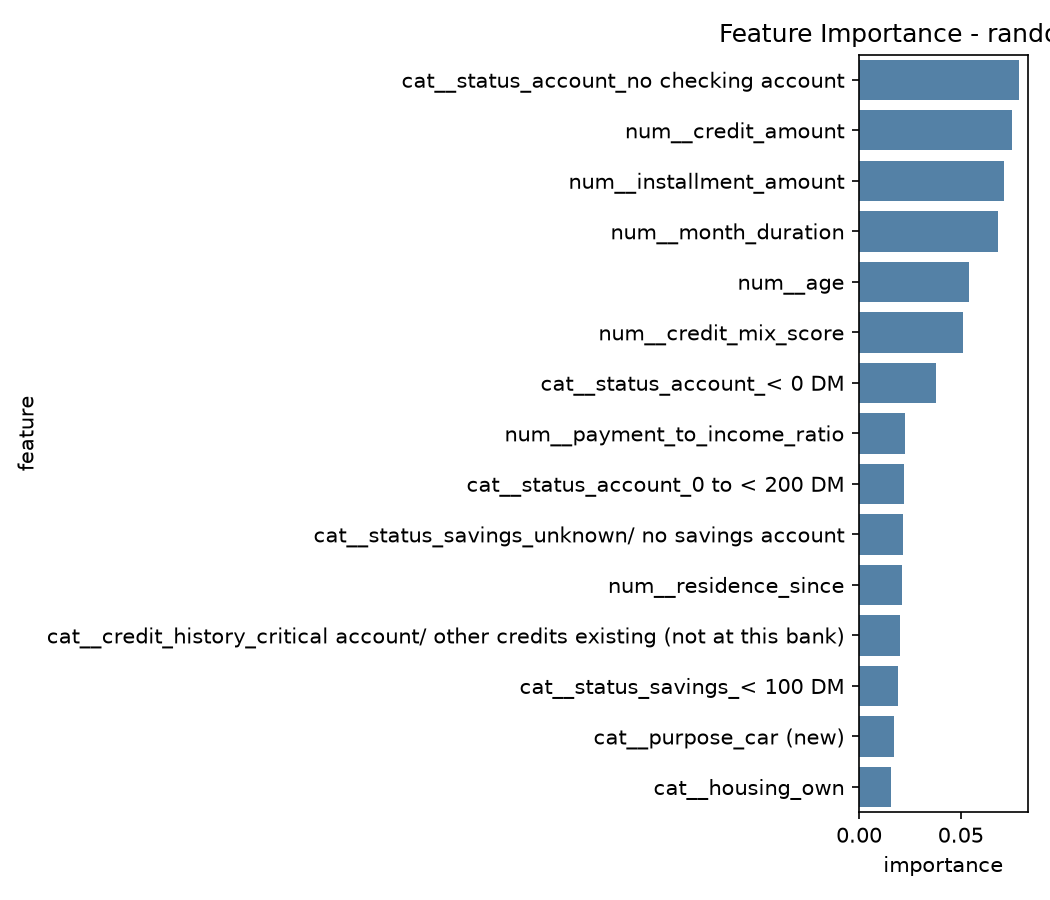

In [6]:
from src.utils import load_model
from src.evaluate import plot_feature_importance
best_pipeline = load_model('best_model.pkl')
plot_feature_importance(best_pipeline, best_model_name)
display(Image(filename=str(FIGURES_DIR / f'feature_importance_{best_model_name}.png')))